run this headless

conda activate guitarmidi
screen jupyter nbconvert --to notebook --execute traning.ipynb --output=output_notebook.ipynb --ExecutePreprocessor.timeout=-1



Mixed precision policy set to 'mixed_float16'.
Memory growth enabled for GPUs.
TensorFlow version: 2.20.0
Loss element-wise weights shape: (89,). Silence weight (index 88) is: 0.05000000074505806


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 312, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 312, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_6             │ (None, 312, 32)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 156, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 156, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 156, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_7             │ (None, 156, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 78, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 78, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 78, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_8             │ (None, 78, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 39, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 89)             │        11,481 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,417 (169.60 KB)

 Trainable params: 42,969 (167.85 KB)

 Non-trainable params: 448 (1.75 KB)

Found 196500 files on disk.

--- Starting CNN Model Training with Sample Weights ---
Epoch 1/100
An error occurred during training: Graph execution error:

Detected at node compile_loss/binary_crossentropy/mul defined at (most recent call last):
<stack traces unavailable>
Incompatible shapes: [16] vs. [16,89]
	 [[{{node compile_loss/binary_crossentropy/mul}}]]
	tf2xla conversion failed while converting __inference_one_step_on_data_2588585[]. Run with TF_DUMP_GRAPH_PREFIX=/path/to/dump/dir and --vmodule=xla_compiler=2 to obtain a dump of the compiled functions.
	 [[StatefulPartitionedCall]] [Op:__inference_multi_step_on_iterator_2588710]


2025-10-07 07:11:05.289370: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at xla_ops.cc:590 : INVALID_ARGUMENT: Incompatible shapes: [16] vs. [16,89]
	 [[{{node compile_loss/binary_crossentropy/mul}}]]
	tf2xla conversion failed while converting __inference_one_step_on_data_2588585[]. Run with TF_DUMP_GRAPH_PREFIX=/path/to/dump/dir and --vmodule=xla_compiler=2 to obtain a dump of the compiled functions.
2025-10-07 07:11:05.289396: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [16] vs. [16,89]
	 [[{{node compile_loss/binary_crossentropy/mul}}]]
	tf2xla conversion failed while converting __inference_one_step_on_data_2588585[]. Run with TF_DUMP_GRAPH_PREFIX=/path/to/dump/dir and --vmodule=xla_compiler=2 to obtain a dump of the compiled functions.
	 [[StatefulPartitionedCall]]


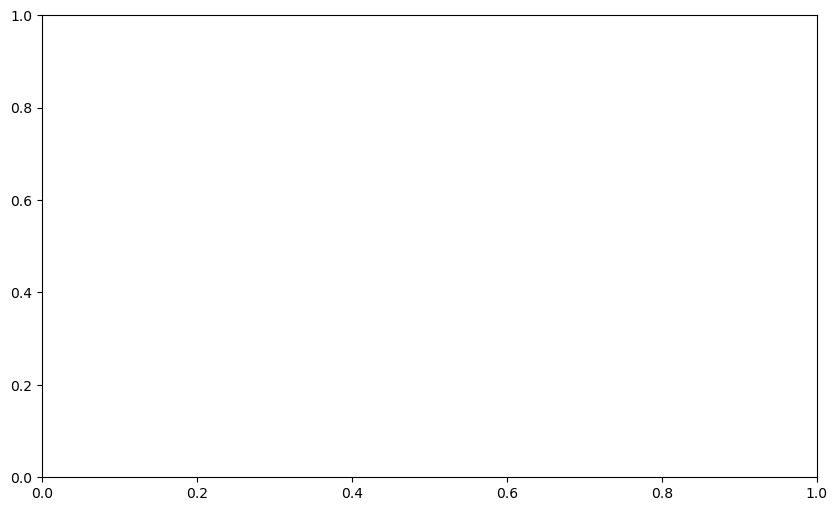

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping
# NO Keras backend import needed now
from model import build_cnn_model # Assumes build_cnn_model is in model.py
import common
from common import INPUT_SHAPE, OUTPUT_DIM_NOTES
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files

# --- 1. GPU Setup ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable Mixed Precision
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision policy set to 'mixed_float16'.")

        for gpu in gpus:
            # Enable memory growth
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print(f"Error configuring GPU: {e}")
# ---------------------------------------------------------------------------------

print(f"TensorFlow version: {tf.__version__}")

# --- 2. Configuration ---
LEARNING_RATE = 0.001
BATCH_SIZE = 16 
EPOCHS = 100

input_data_dir = 'data_slices/input'
output_data_dir = 'data_slices/output'

# --- 3. Loss Weight Configuration (Using `class_weight` for `model.fit`) ---
# NOTE: The term 'class_weight' in model.fit is typically used for samples,
# but for multi-label problems, a simpler approach is to use the `sample_weight`
# argument (see Section 7) or to define a specific weight vector to apply 
# to the loss element-wise for the entire output vector. 

# Since you want to weight the 89th *output element* differently, and 
# NOT the entire sample, the most straightforward way using built-in loss 
# is to utilize the `sample_weight` argument in `model.fit`. 

# We will create a *per-output weight* vector and pass it as sample_weight
# along with the data. This is the official Keras way to handle per-output weighting 
# for a built-in loss function.

NOTE_WEIGHT = 1.0 
SILENCE_WEIGHT = 0.05 # Example: Weight for the 89th output element (index 88)

# The weight array must have the shape of the output (OUTPUT_DIM_NOTES,)
# This array will be broadcast across the batch and time dimensions.
element_weights = np.full((common.OUTPUT_DIM_NOTES,), NOTE_WEIGHT, dtype=np.float32)
element_weights[-1] = SILENCE_WEIGHT 
print(f"Loss element-wise weights shape: {element_weights.shape}. Silence weight (index {common.OUTPUT_DIM_NOTES-1}) is: {element_weights[-1]}")


# --- 4. Model Definition and Compilation (Using built-in loss) ---

cnn_model = build_cnn_model(common.INPUT_SHAPE, common.OUTPUT_DIM_NOTES)
cnn_model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='binary_crossentropy', # <-- USING BUILT-IN LOSS
                  metrics=['accuracy'])

cnn_model.summary()


# --- 5. Custom Callback for Live Loss Plotting (omitted for brevity, assume definition remains the same) ---
class PlotLoss(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = []
        self.val_losses = []
        self.epochs_run = []
        self.fig, self.ax = plt.subplots(figsize=(10, 6))

    def on_epoch_end(self, epoch, logs={}):
        self.losses.append(logs.get('loss'))
        if logs.get('val_loss') is not None:
            self.val_losses.append(logs.get('val_loss'))
        self.epochs_run.append(epoch + 1)

        clear_output(wait=True)
        self.ax.clear()
        self.ax.plot(self.epochs_run, self.losses, label='Training Loss')
        if self.val_losses:
            self.ax.plot(self.epochs_run, self.val_losses, label='Validation Loss')
        self.ax.set_xlabel('Epoch')
        self.ax.set_ylabel('Loss')
        self.ax.set_title('Training and Validation Loss Over Epochs')
        self.ax.legend()
        self.ax.grid(True)
        plt.savefig("training.png")
        plt.show()

# --- 6. Data Loading and Preparation (Modified to include weights) ---

input_filepaths = sorted(glob.glob(os.path.join(input_data_dir, '*.npy')))
output_filepaths = sorted(glob.glob(os.path.join(output_data_dir, '*.npy')))

total_samples_on_disk = len(input_filepaths)
if total_samples_on_disk == 0 or total_samples_on_disk != len(output_filepaths):
    print("ERROR: Data files not found or mismatch.")
    exit()

print(f"Found {total_samples_on_disk} files on disk.")

# We need to map the data to (feature, label, weight) tuples for tf.data
# The weight for each sample will be the 'element_weights' vector defined above.

def load_sample_from_files(input_path_tensor, output_path_tensor):
    input_path = input_path_tensor.numpy().decode('utf-8')
    output_path = output_path_tensor.numpy().decode('utf-8')

    # Load data
    image = np.load(input_path).astype(np.float32).reshape(INPUT_SHAPE)
    label = np.load(output_path).astype(np.float32).reshape(common.OUTPUT_DIM_NOTES)

    # Ensure shape
    image = tf.ensure_shape(image, INPUT_SHAPE)
    label = tf.ensure_shape(label, (common.OUTPUT_DIM_NOTES,)) 
    
    # Return features and label
    return image, label


def tf_load_sample_from_files(ipath, opath):
    image, label = tf.py_function(
        load_sample_from_files, [ipath, opath], [tf.float32, tf.float32]
    )
    image.set_shape(INPUT_SHAPE)
    label.set_shape((common.OUTPUT_DIM_NOTES,))
    # The crucial step: Add the element_weights tensor to each sample
    weight = tf.constant(element_weights, dtype=tf.float32)
    return image, label, weight # Return (features, labels, sample_weights)
def batch_with_weights(dataset):
    def _stack_fn(images, labels, weights):
        return (tf.stack(images), tf.stack(labels), tf.stack(weights))
    return dataset.batch(BATCH_SIZE).map(_stack_fn, num_parallel_calls=tf.data.AUTOTUNE)

# Create a dataset from the lists of file paths
dataset = tf.data.Dataset.from_tensor_slices((input_filepaths, output_filepaths))
dataset = dataset.shuffle(buffer_size=total_samples_on_disk)

split_ratio = 0.7
num_train = int(total_samples_on_disk * split_ratio)

train_dataset = dataset.take(num_train)
val_dataset = dataset.skip(num_train)

# Map loading function (now includes the weight vector)
train_dataset = train_dataset.map(tf_load_sample_from_files, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.map(tf_load_sample_from_files, num_parallel_calls=tf.data.AUTOTUNE)

# Apply batching and prefetching
# train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
# val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
train_dataset = batch_with_weights(train_dataset).prefetch(tf.data.AUTOTUNE)
val_dataset = batch_with_weights(val_dataset).prefetch(tf.data.AUTOTUNE)

# --- 7. Training the Model (Passing the element-wise weight) ---

plot_callback = PlotLoss()
early_stopping_callback = EarlyStopping(
    monitor='val_loss', 
    patience=5,   
    min_delta=0.0001, 
    mode='min',          
    verbose=1,           
    restore_best_weights=True
)

print("\n--- Starting CNN Model Training with Sample Weights ---")
try:
    # Keras expects (features, labels, sample_weights) when sample_weights are present
    history_cnn = cnn_model.fit(train_dataset,
                                epochs=EPOCHS,
                                validation_data=val_dataset,
                                callbacks=[plot_callback, early_stopping_callback])
    
    cnn_model.save_weights('guitarmidi.weights.h5')
    print("Model weights saved successfully!")
    
except Exception as e:
    print(f"An error occurred during training: {e}")